<a href="https://colab.research.google.com/github/JACKARPANJACK/AI-Lab-6th-sem/blob/main/A__tradeoff_robot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Algorithm Comparison:

Algorithm       Steps      Cost       Explored   Time(ms)  
A* Manhattan    18         18.00      31         0.17      
A* Euclidean    12         14.49      24         0.18      
UCS             12         14.49      58         0.35      
BFS             12         12.00      57         0.25      


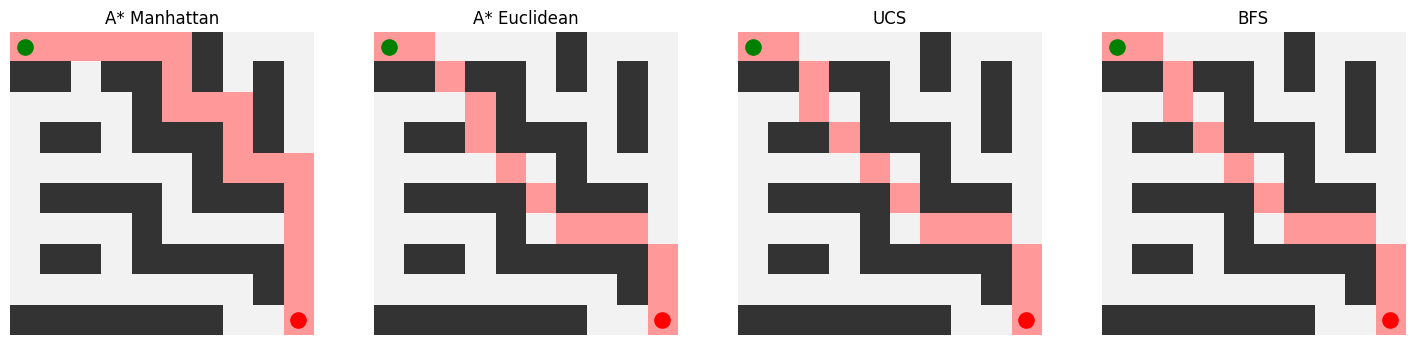

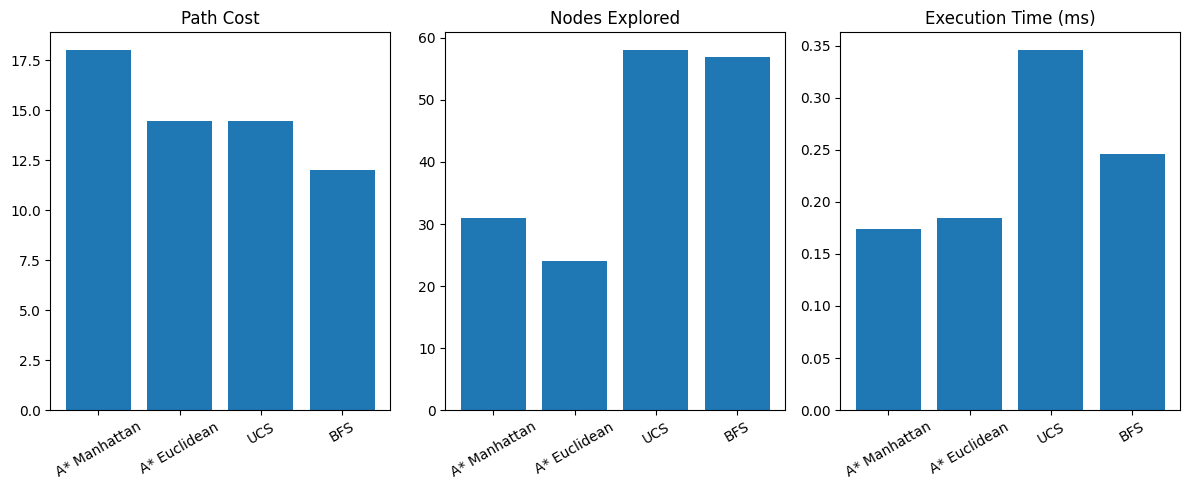

In [ ]:
import heapq
import math
import time
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

GRID = [
[0,0,0,0,0,0,1,0,0,0],
[1,1,0,1,1,0,1,0,1,0],
[0,0,0,0,1,0,0,0,1,0],
[0,1,1,0,1,1,1,0,1,0],
[0,0,0,0,0,0,1,0,0,0],
[0,1,1,1,1,0,1,1,1,0],
[0,0,0,0,1,0,0,0,0,0],
[0,1,1,0,1,1,1,1,1,0],
[0,0,0,0,0,0,0,0,1,0],
[1,1,1,1,1,1,1,0,0,0]
]

ROWS = len(GRID)
COLS = len(GRID[0])
START = (0,0)
GOAL  = (9,9)

#Heuristic function for A* (Manhattan distance)
def manhattan(a,b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def euclidean(a,b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)


CARDINAL = [(-1,0),(1,0),(0,-1),(0,1)]
DIAGONAL = CARDINAL + [(-1,-1),(-1,1),(1,-1),(1,1)]

def get_neighbors(node, diagonal=False):
    directions = DIAGONAL if diagonal else CARDINAL
    neighbors = []

    for dr,dc in directions:
        r = node[0] + dr
        c = node[1] + dc

        if 0 <= r < ROWS and 0 <= c < COLS and GRID[r][c] == 0:
            cost = math.sqrt(2) if (dr!=0 and dc!=0) else 1
            neighbors.append(((r,c),cost))
    return neighbors

def reconstruct_path(came_from,current):
    path=[]
    while current in came_from:
        path.append(current)
        current=came_from[current]
    path.append(current)
    return path[::-1]

# 5. A* SEARCH

def astar(start,goal,heuristic,diagonal=False):
    open_set=[(0,start)]
    came_from={}
    g_score={start:0}
    explored=0

    while open_set:
        _,current=heapq.heappop(open_set)
        explored+=1

        if current==goal:
            return reconstruct_path(came_from,goal), explored, g_score[goal]

        for neighbor,move_cost in get_neighbors(current,diagonal):
            tentative=g_score[current]+move_cost

            if tentative < g_score.get(neighbor,float('inf')):
                came_from[neighbor]=current
                g_score[neighbor]=tentative
                f=tentative+heuristic(neighbor,goal)
                heapq.heappush(open_set,(f,neighbor))

    return None,explored,float('inf')

#UCS is just A* with heuristic=0
def ucs(start,goal,diagonal=False):
    return astar(start,goal,lambda a,b: 0,diagonal)

#bfs is A* with heuristic=0 and uniform cost
def bfs(start,goal,diagonal=False):
    open_set=deque([start])
    came_from={}
    explored=0

    while open_set:
        current=open_set.popleft()
        explored+=1

        if current==goal:
            return reconstruct_path(came_from,goal), explored, len(reconstruct_path(came_from,goal))-1

        for neighbor,_ in get_neighbors(current,diagonal):
            if neighbor not in came_from and neighbor!=start:
                came_from[neighbor]=current
                open_set.append(neighbor)

    return None,explored,float('inf')

def run(name,fn,*args):
    t0=time.perf_counter()
    path,explored,cost=fn(*args)
    elapsed=(time.perf_counter()-t0)*1000

    return {
        "name":name,
        "path":path,
        "path_len":len(path)-1 if path else 0,
        "explored":explored,
        "cost":cost,
        "time":elapsed
    }

results=[
run("A* Manhattan",astar,START,GOAL,manhattan,False),
run("A* Euclidean",astar,START,GOAL,euclidean,True),
run("UCS",ucs,START,GOAL,True),
run("BFS",bfs,START,GOAL,True)
]

# 9. PRINT TABLE

print("\nAlgorithm Comparison:\n")
print("{:<15} {:<10} {:<10} {:<10} {:<10}".format("Algorithm","Steps","Cost","Explored","Time(ms)"))
for r in results:
    print("{:<15} {:<10} {:<10.2f} {:<10} {:<10.2f}".format(r["name"],r["path_len"],r["cost"],r["explored"],r["time"]))

# 10. VISUALIZATION

fig,axs=plt.subplots(1,4,figsize=(18,4))

colors=["red","blue","green","purple"]

for ax,res,color in zip(axs,results,colors):
    bg=np.ones((ROWS,COLS,3))*0.95

    for r in range(ROWS):
        for c in range(COLS):
            if GRID[r][c]==1:
                bg[r,c]=[0.2,0.2,0.2]

    if res["path"]:
        for pr,pc in res["path"]:
            bg[pr,pc]=[1,0.6,0.6]

    ax.imshow(bg)
    ax.scatter(START[1],START[0],c='green',s=120)
    ax.scatter(GOAL[1],GOAL[0],c='red',s=120)
    ax.set_title(res["name"])
    ax.axis('off')

plt.show()

# 11. BAR CHART
labels=[r["name"] for r in results]
costs=[r["cost"] for r in results]
explored=[r["explored"] for r in results]
times=[r["time"] for r in results]

plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.bar(labels,costs)
plt.title("Path Cost")
plt.xticks(rotation=30)

plt.subplot(1,3,2)
plt.bar(labels,explored)
plt.title("Nodes Explored")
plt.xticks(rotation=30)

plt.subplot(1,3,3)
plt.bar(labels,times)
plt.title("Execution Time (ms)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()